In [1]:


import mouse_viz as mvz
import data_wrangling
import pathlib
import os




data_dir = pathlib.Path('/Users/ethan/Documents/GitHub/ReadingComprehension/Mouse-tracking/data/jatos_results_20260224151143/')

# find all the non- labjs data files and put filenames in a list
files = sorted(os.listdir(data_dir / 'raw_data'))              
files
                                              
filenames = []
for file in files:
    raw = data_dir / 'raw_data' / file
    df = data_wrangling.parse_labjs_data(raw, False)     
    if df is None:                                  
        filenames.append(data_dir / 'raw_data' / file)


raw_data_dir = data_dir / 'raw_data'


data = mvz.build_data(filenames)
df = mvz.build_dataframe(data, data_dir=raw_data_dir)




labjs data found and imported 👍
This file does not appear to be in lab.js format
This file does not appear to be in lab.js format
labjs data found and imported 👍
This file does not appear to be in lab.js format
This file does not appear to be in lab.js format
labjs data found and imported 👍
This file does not appear to be in lab.js format
This file does not appear to be in lab.js format


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np


def plot_group_heatmap(df, text_content, group_value,
                       group_field='ordblindhed', title=None, figsize=(14, 6)):
    """
    Plot a heatmap of mean reading times across participants
    for a given text and diagnostic group.
    """
    subset = df[(df['text_content'] == text_content) &
                (df[group_field] == group_value)]

    if subset.empty:
        print(f"No data for {group_field}='{group_value}' on this text.")
        return None

    n_participants = subset['participant_id'].nunique()

    # Mean duration per word position
    mean_dur = subset.groupby('word_number')['duration_ms'].mean().reset_index()

    # Use the first participant's layout as spatial template
    first_pid = subset['participant_id'].iloc[0]
    layout = subset[subset['participant_id'] == first_pid][
        ['word_number', 'word', 'x_start', 'x_end', 'y_position', 'line_number']
    ].drop_duplicates(subset='word_number')

    plot_df = layout.merge(mean_dur, on='word_number')

    canvas_width  = subset['canvas_width'].iloc[0]
    canvas_height = subset['canvas_height'].iloc[0]

    # Add a title
    if title is None:
        preview = text_content[:60] + '...' if len(text_content) > 60 else text_content
        label = 'Dyslexic' if group_value == 'ja-o' else 'Non-dyslexic' \
                if group_value == 'nej-o' else group_value
        title = (f"Mean Reading Times — {label} (n={n_participants})\n"
                 f"\"{preview}\"")

    # Make the plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, canvas_width)
    ax.set_ylim(canvas_height, 0)

    colors = ['#ffffff', '#fff3e0', '#ffcc80', '#ff9800', '#f44336', '#b71c1c']
    cmap = LinearSegmentedColormap.from_list('duration', colors)

    min_d = plot_df['duration_ms'].min()
    max_d = plot_df['duration_ms'].max()
    d_range = max_d - min_d if max_d != min_d else 1

    for _, row in plot_df.iterrows():
        norm = (row['duration_ms'] - min_d) / d_range
        color = cmap(norm)
        rect = plt.Rectangle(
            (row['x_start'], row['y_position'] - 20),
            row['x_end'] - row['x_start'], 24,
            color=color, zorder=1
        )
        ax.add_patch(rect)
        ax.text(
            (row['x_start'] + row['x_end']) / 2, row['y_position'],
            row['word'], ha='center', va='center', fontsize=9, zorder=2
        )

    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=min_d, vmax=max_d))
    sm.set_array([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=-0.05)
    plt.colorbar(sm, cax=cax, label='Mean Duration (ms)', orientation='horizontal')

    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    return fig


def plot_group_comparison(df, text_content, group_field='ordblindhed',
                          figsize=(14, 12)):
    """
    Plot dyslexic vs non-dyslexic heatmaps side-by-side (stacked vertically)
    for a single text, using a shared color scale for direct comparison.
    """
    groups = sorted(df[df['text_content'] == text_content][group_field]
                    .dropna().unique())

    if len(groups) < 2:
        print(f"Only {len(groups)} group(s) found. Need at least 2 for comparison.")
        return None

    # Compute global min/max across both groups for a shared color scale
    text_data = df[df['text_content'] == text_content]
    global_min = text_data.groupby('word_number')['duration_ms'].mean().min()
    global_max = text_data.groupby('word_number')['duration_ms'].mean().max()

    colors = ['#ffffff', '#fff3e0', '#ffcc80', '#ff9800', '#f44336', '#b71c1c']
    cmap = LinearSegmentedColormap.from_list('duration', colors)
    d_range = global_max - global_min if global_max != global_min else 1

    fig, axes = plt.subplots(len(groups), 1, figsize=figsize)
    if len(groups) == 1:
        axes = [axes]

    for ax, group_value in zip(axes, groups):
        subset = text_data[text_data[group_field] == group_value]
        n_participants = subset['participant_id'].nunique()

        mean_dur = subset.groupby('word_number')['duration_ms'].mean().reset_index()

        first_pid = subset['participant_id'].iloc[0]
        layout = subset[subset['participant_id'] == first_pid][
            ['word_number', 'word', 'x_start', 'x_end', 'y_position', 'line_number']
        ].drop_duplicates(subset='word_number')

        plot_df = layout.merge(mean_dur, on='word_number')

        canvas_width  = subset['canvas_width'].iloc[0]
        canvas_height = subset['canvas_height'].iloc[0]

        ax.set_xlim(0, canvas_width)
        ax.set_ylim(canvas_height, 0)

        for _, row in plot_df.iterrows():
            norm = (row['duration_ms'] - global_min) / d_range
            color = cmap(norm)
            rect = plt.Rectangle(
                (row['x_start'], row['y_position'] - 20),
                row['x_end'] - row['x_start'], 24,
                color=color, zorder=1
            )
            ax.add_patch(rect)
            ax.text(
                (row['x_start'] + row['x_end']) / 2, row['y_position'],
                row['word'], ha='center', va='center', fontsize=9, zorder=2
            )

        label = 'Dyslexic' if group_value == 'ja-o' else 'Non-dyslexic' \
                if group_value == 'nej-o' else group_value
        ax.set_title(f"{label} (n={n_participants})")
        ax.axis('off')

    # Shared colorbar at the bottom
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=global_min, vmax=global_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='horizontal',
                         fraction=0.03, pad=0.04, label='Mean Duration (ms)')

    preview = text_content[:60] + '...' if len(text_content) > 60 else text_content
    fig.suptitle(f"Reading Time Comparison\n\"{preview}\"", fontsize=13, y=1.02)
    plt.tight_layout()
    return fig


def plot_all_group_heatmaps(df, group_field='ordblindhed', figsize=(14, 6)):
    """
    Generate mean-duration heatmaps for every text × group combination.
    """
    texts  = df['text_content'].unique()
    groups = df[group_field].dropna().unique()

    figs = []
    for text in texts:
        for group in sorted(groups):
            fig = plot_group_heatmap(df, text, group,
                                     group_field=group_field, figsize=figsize)
            if fig is not None:
                figs.append(fig)
    return figs


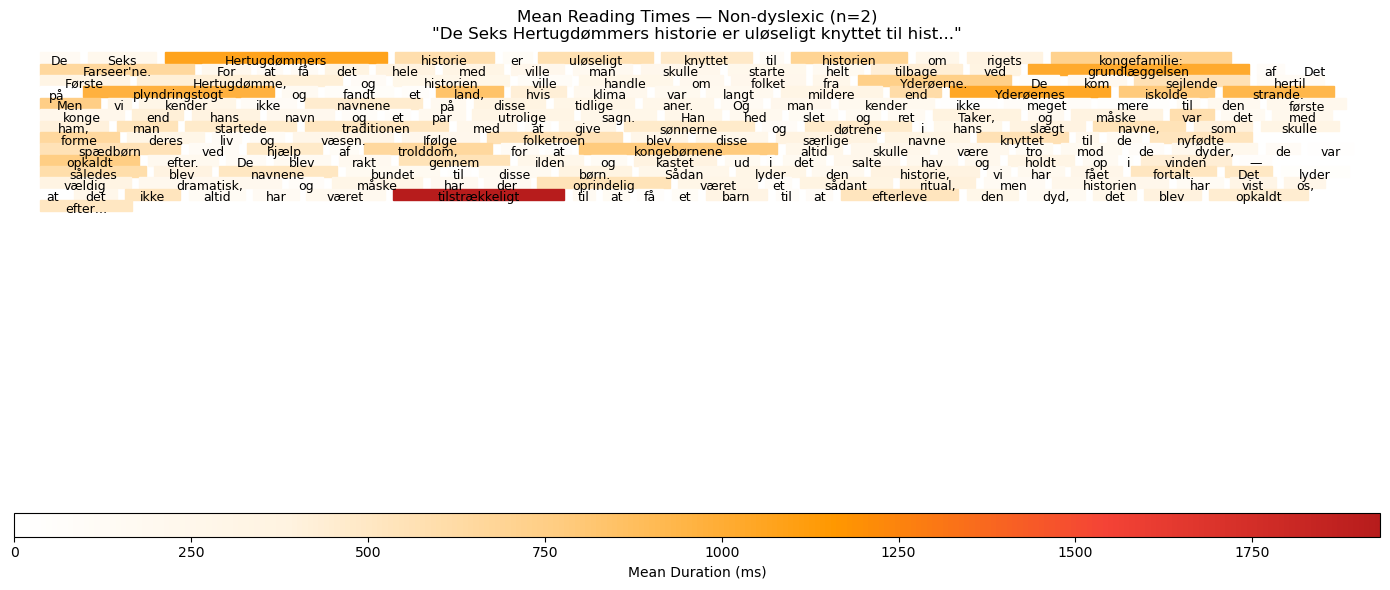

In [3]:

# --- Single group, single text ---
texts = df['text_content'].unique()
fig = plot_group_heatmap(df, texts[0], group_value='nej-o')
plt.show()

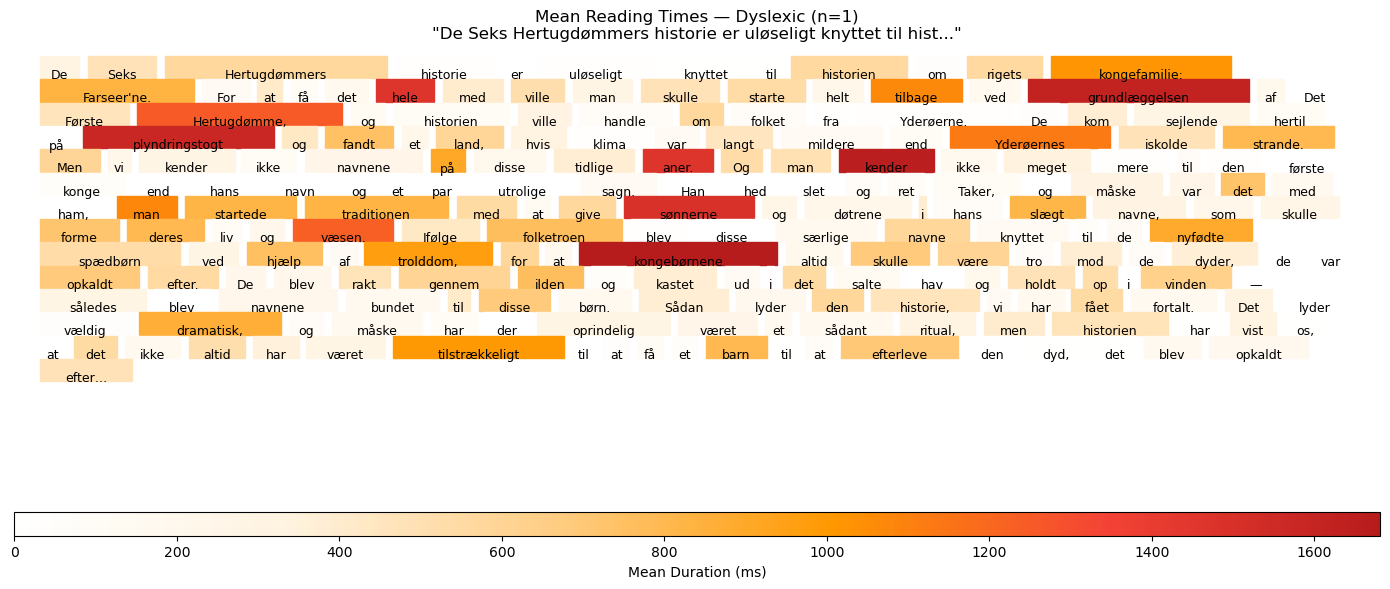

In [4]:

# --- Single group, single text ---
texts = df['text_content'].unique()
fig = plot_group_heatmap(df, texts[0], group_value='ja-o')
plt.show()

/var/folders/6m/mwt0c30539b1zrk5vf14dpr44pd98r/T/ipykernel_85666/2108477082.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


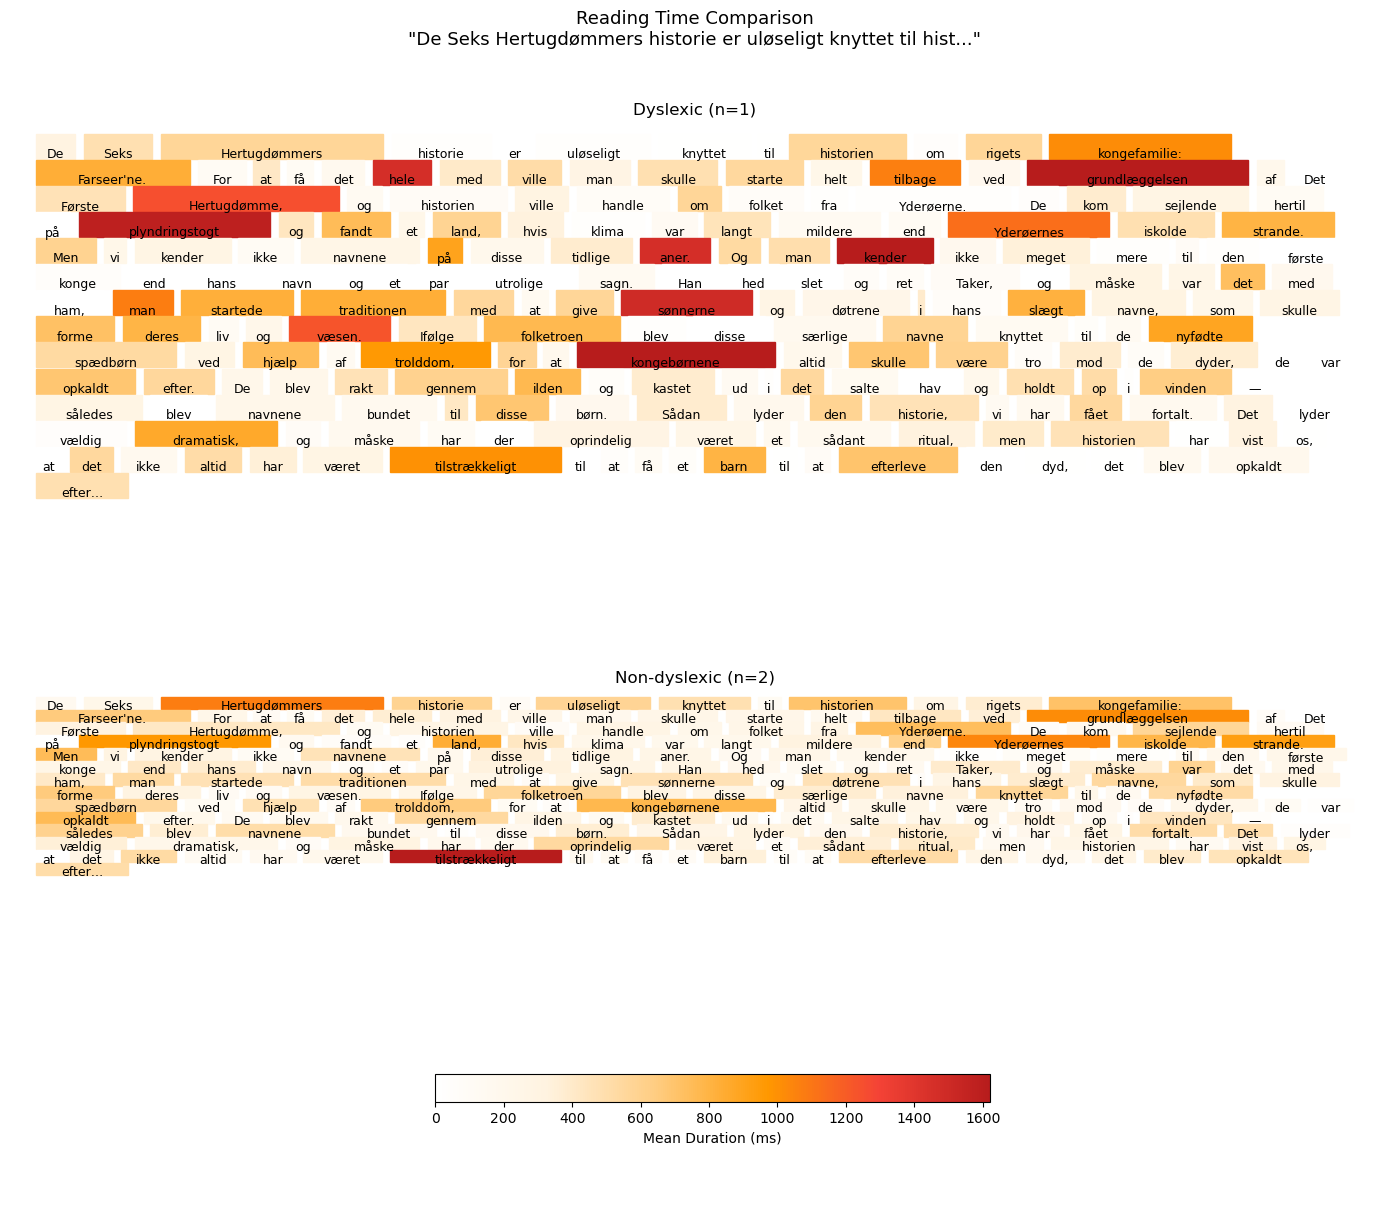

In [5]:
# --- Side-by-side comparison for one text ---
fig = plot_group_comparison(df, texts[0])
plt.show()

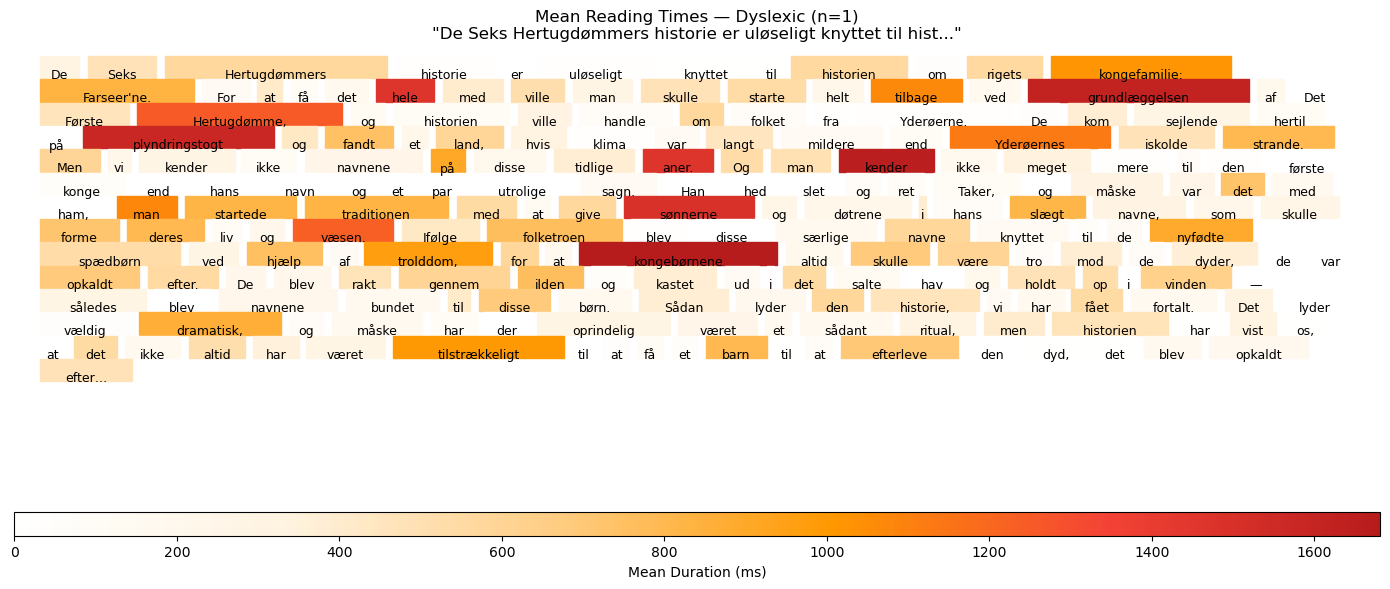

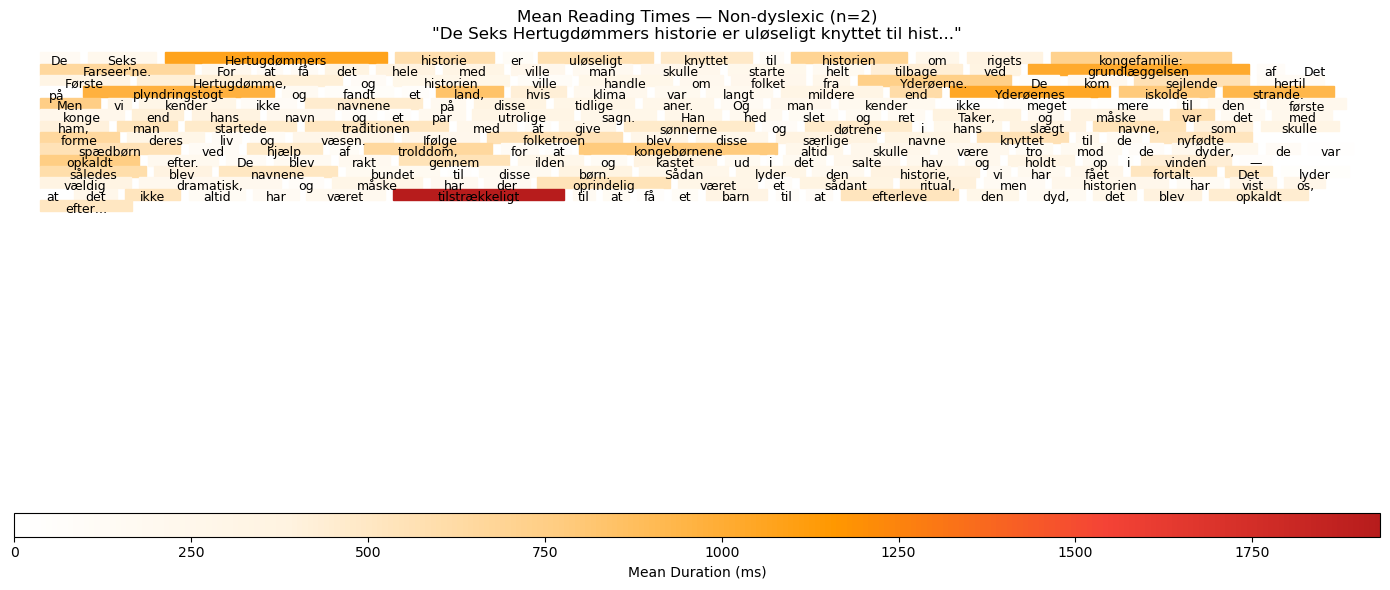

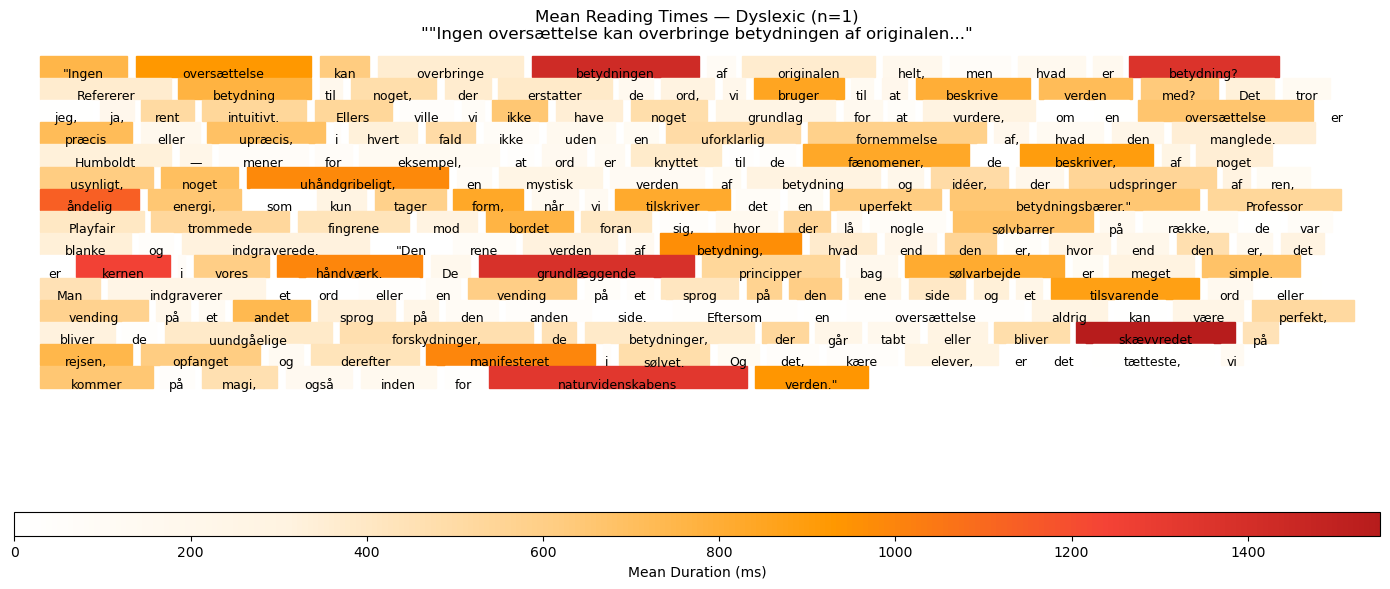

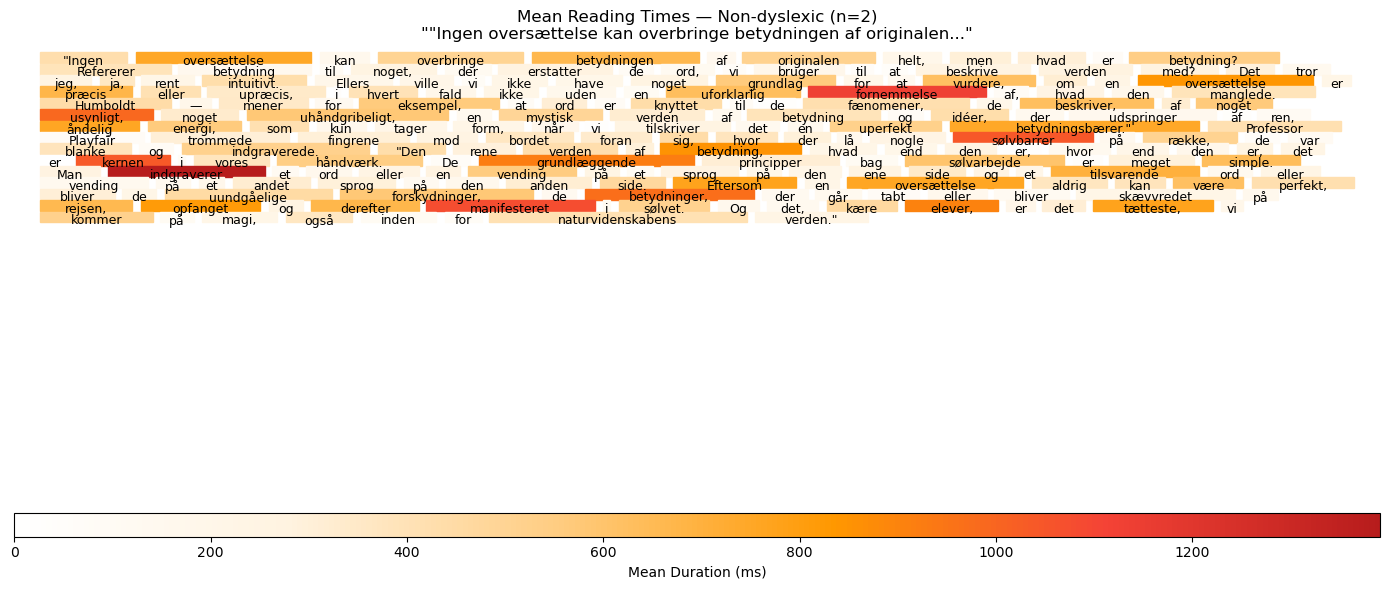

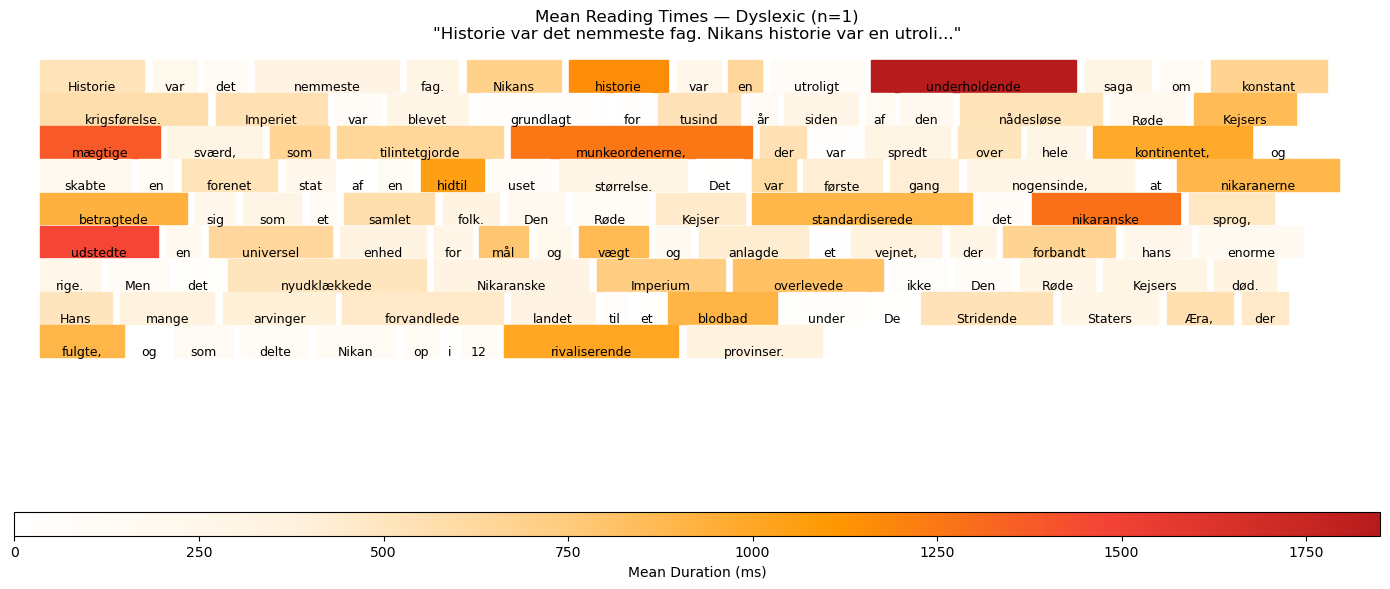

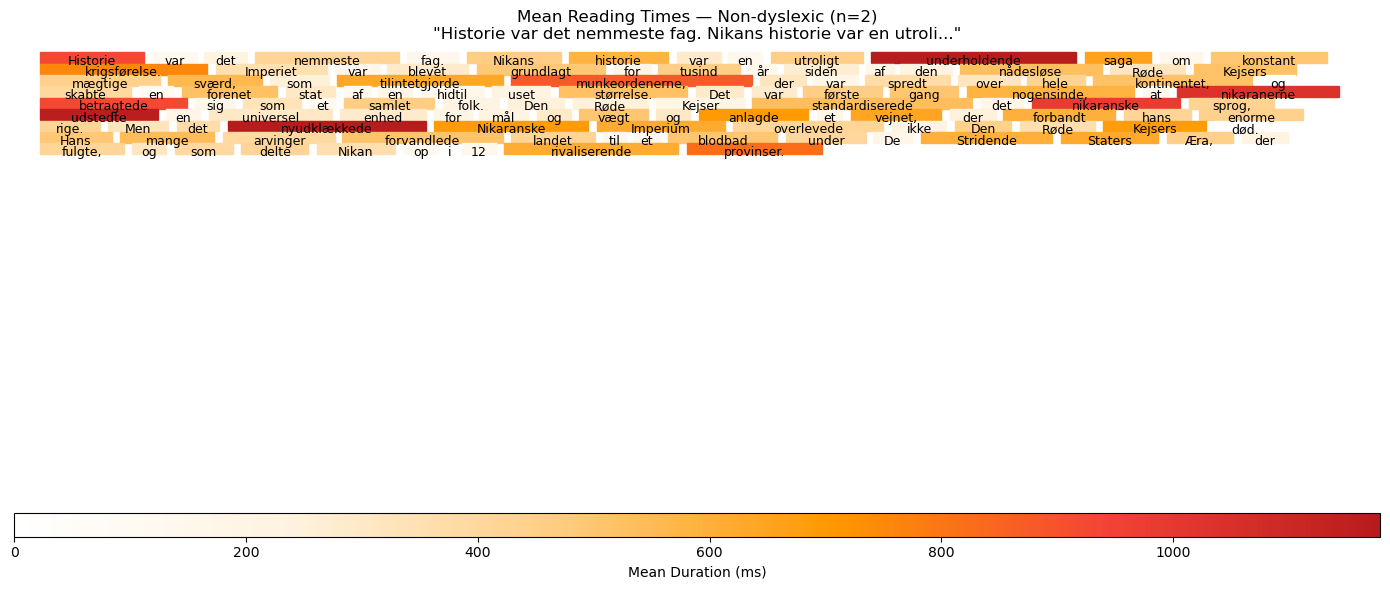

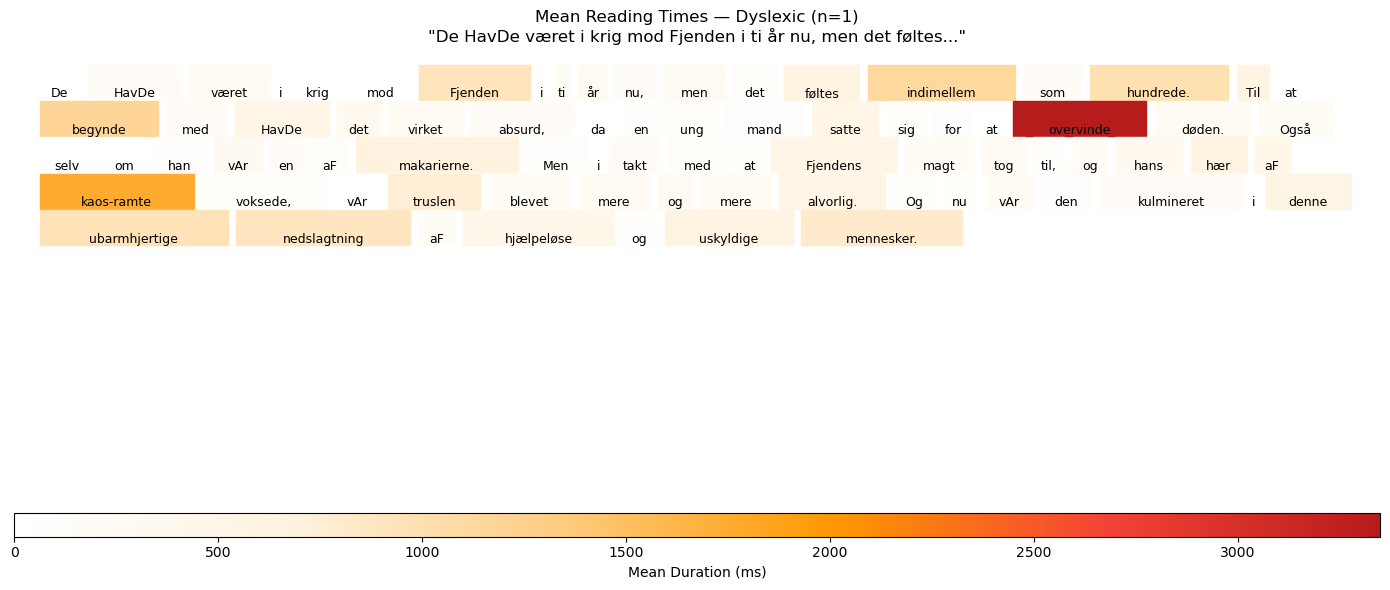

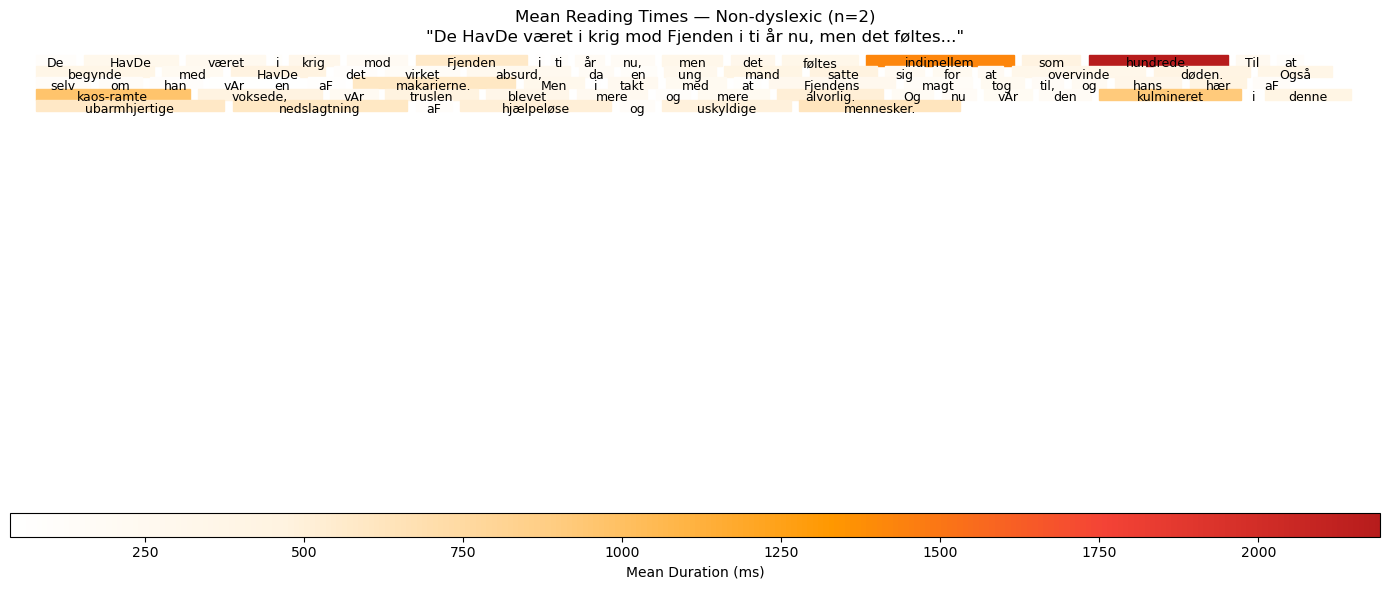

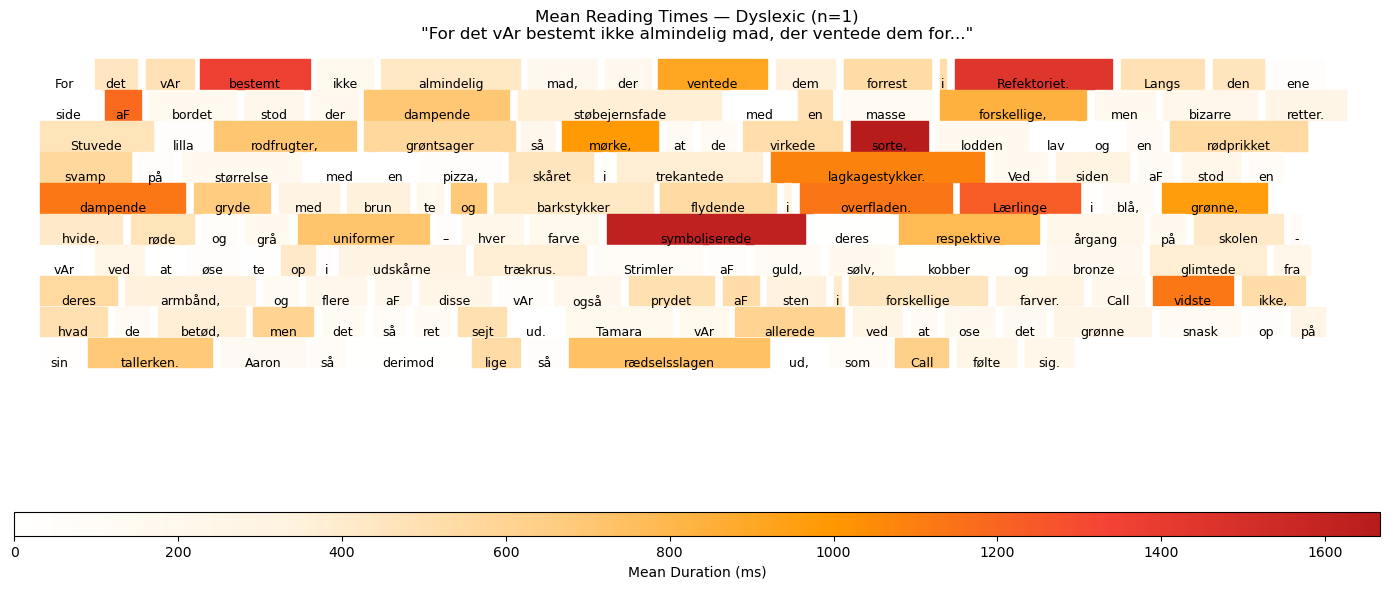

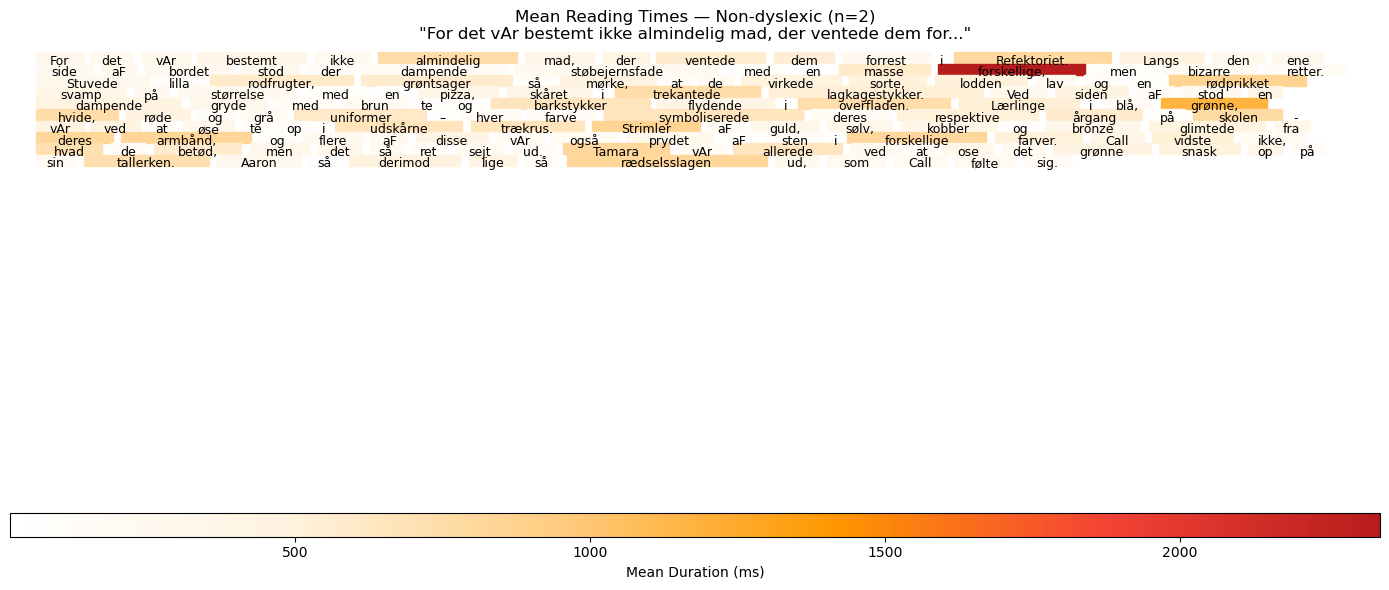

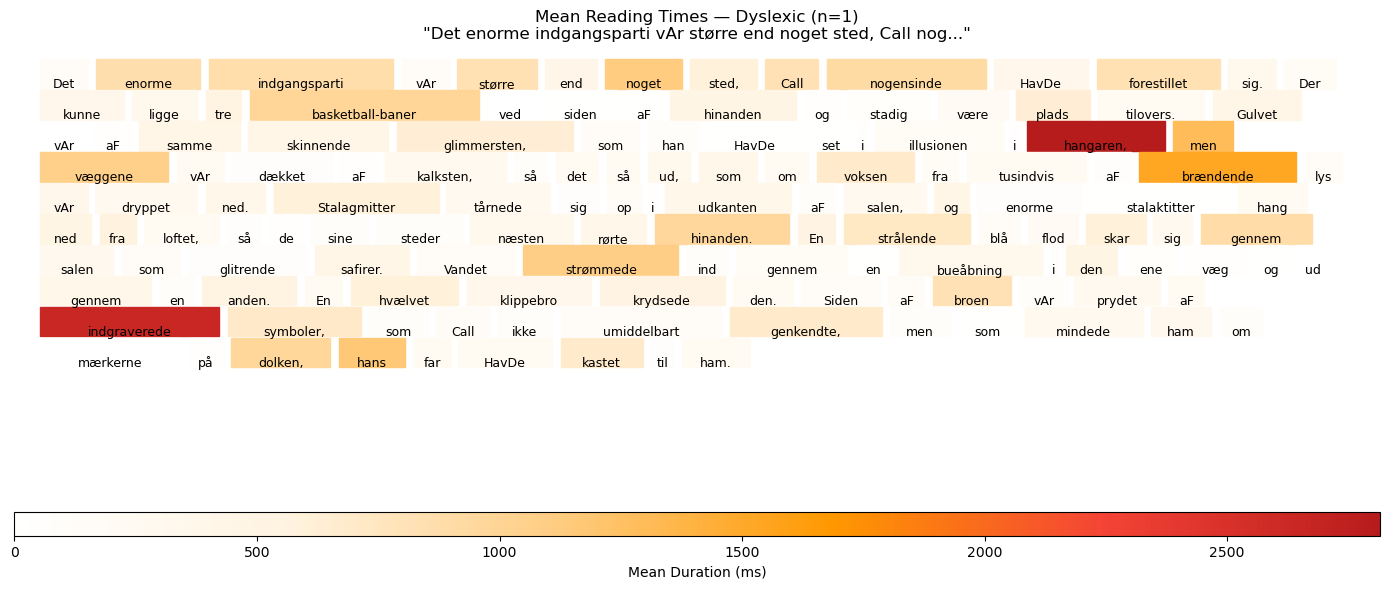

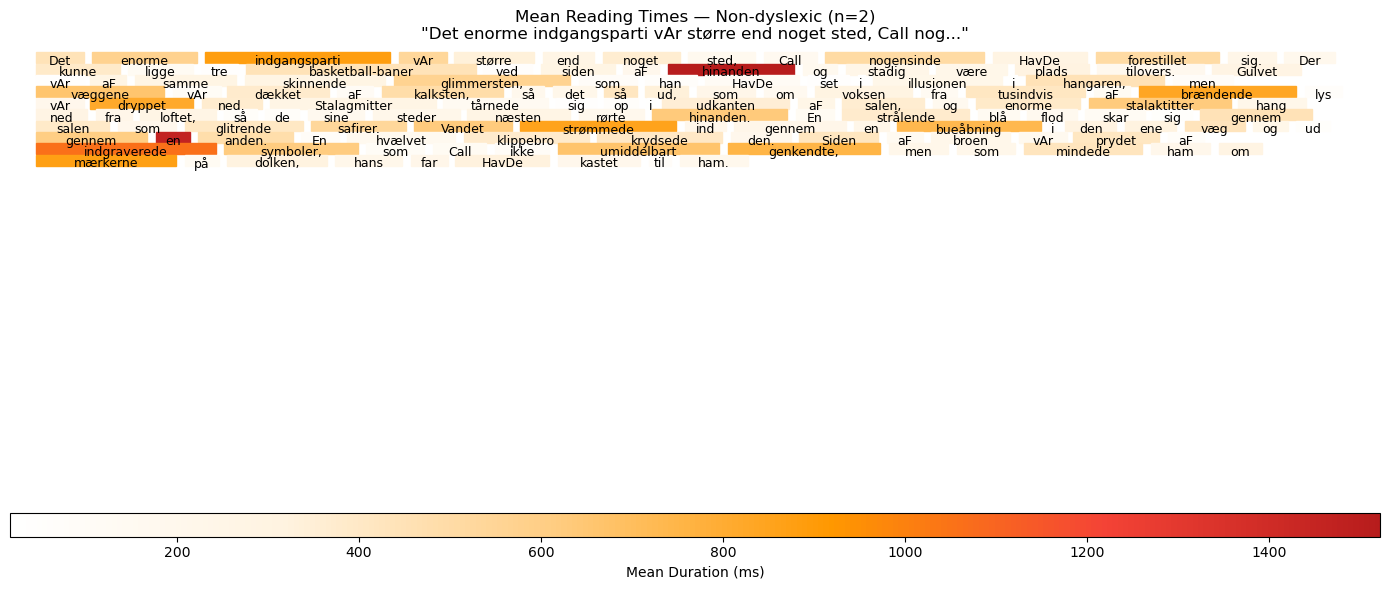

In [6]:
# --- All texts, all groups ---
figs = plot_all_group_heatmaps(df)
for fig in figs:
    plt.show()

In [ ]:
import json
import os
import re
import pandas as pd

DEMO_FIELDS = ['køn', 'alder', 'modersmål', 'uddannelse',
               'læsning', 'familie', 'ordblindhed', 'ordtest']

def extract_demographics_from_file(filepath):
    demographics = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read().strip()

    json_objects = []
    try:
        parsed = json.loads(content)
        if isinstance(parsed, list):
            json_objects = parsed
        elif isinstance(parsed, dict):
            json_objects = [parsed]
    except json.JSONDecodeError:
        pass

    if not json_objects:
        for line in content.split('\n'):
            line = line.strip().rstrip(',')
            if not line:
                continue
            try:
                json_objects.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    if not json_objects:
        for match in re.finditer(r'\{[^{}]+\}', content):
            try:
                json_objects.append(json.loads(match.group()))
            except json.JSONDecodeError:
                continue

    for obj in json_objects:
        if not isinstance(obj, dict):
            continue
        if obj.get('sender_type') == 'html.Form':
            for field in DEMO_FIELDS:
                if field in obj and field not in demographics:
                    demographics[field] = obj[field]
    return demographics


def build_demographics_lookup(data_dir):
    lookup = {}
    for fname in sorted(os.listdir(data_dir)):
        if fname.endswith('_1.txt'):
            prefix = fname.replace('_1.txt', '')
            filepath = os.path.join(data_dir, fname)
            demo = extract_demographics_from_file(filepath)
            print(f"  {fname} -> prefix '{prefix}' -> {demo}")
            lookup[prefix] = demo
    return lookup


def get_participant_prefix(participant_id):
    match = re.match(r'^(\d+)', str(participant_id))
    return match.group(1) if match else str(participant_id)


def build_dataframe(data, data_dir):
    demo_lookup = build_demographics_lookup(data_dir)

    frames = []
    for trial in data:
        wdf = trial['word_durations'].copy()
        wdf['participant_id'] = trial['participant_id']
        wdf['trial_num']      = trial['trial_num']
        wdf['text_content']   = trial['text_content']
        wdf['canvas_width']   = trial['canvas_width']
        wdf['canvas_height']  = trial['canvas_height']

        prefix = get_participant_prefix(trial['participant_id'])
        demo = demo_lookup.get(prefix, {})
        for field in DEMO_FIELDS:
            wdf[field] = demo.get(field, None)

        frames.append(wdf)

    return pd.concat(frames, ignore_index=True)



In [ ]:
from matplotlib import pyplot as plt
for trial in data:
    fig_width  = max(10, trial['canvas_width'] / 110)
    fig_height = max(4,  trial['canvas_height'] / 110)

    fig = mvz.plot_text_heatmap(trial, figsize=(fig_width, fig_height))
    plt.show()

In [ ]:
figs = mvz.plot_all_group_heatmaps(data, group_field='ordblindhed')
for fig in figs:
    plt.show()